In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [24]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [37]:
import numpy as np
import pandas as pd
from numpy import mean
from numpy import std
from matplotlib import pyplot as plt
from sklearn.model_selection import KFold
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dropout, BatchNormalization, MaxPool2D

In [26]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()


unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ", dict(zip(unique, counts)))

unique, counts = np.unique(y_test, return_counts=True)
print("\nTest labels: ", dict(zip(unique, counts)))

Train labels:  {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}

Test labels:  {np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


In [27]:
labels = len(np.unique(y_train))
print(labels)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

10
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


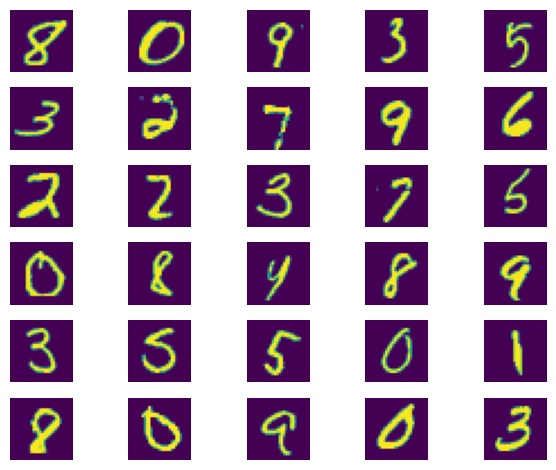

In [28]:
index = np.random.randint(0, x_train.shape[0], size=30)
images = x_train[index]
#labels = y_train[index]

for i in range(len(index)):
    plt.subplot(6,5,i+1)
    plt.imshow(images[i])   # images (28,28,3)
    plt.axis('off')

plt.tight_layout()

plt.savefig("mnist.png")  # save figure
plt.show()
plt.close('all')

In [29]:
print(len(x_train))
print(len(x_test))

60000
10000


In [30]:
x_train.shape

(60000, 28, 28)

In [31]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [32]:
x_train.shape

(60000, 28, 28, 1)

In [33]:
y_cat_train = to_categorical(y_train, 10)    # Convert the labels from 0-9 to one hot encoded 10-dimensional vectors
y_cat_test = to_categorical(y_test, 10)      # Convert the labels from 0-9 to one hot encoded 10-dimensional vectors

x_train1, x_valid, y_train1, y_valid= train_test_split(x_train, y_cat_train, test_size=0.2, random_state=22)
train_datagen = ImageDataGenerator(    #standard augmentation
                    rotation_range=10,
                    rescale=1./255,
                    zoom_range=0.1,
                    fill_mode='nearest',
                    horizontal_flip=True,
                    width_shift_range=0.1,
                    height_shift_range=0.1
                    )

valid_datagen = ImageDataGenerator(    #standard augmentation
                    rotation_range=10,
                    rescale=1./255,
                    zoom_range=0.1,
                    fill_mode='nearest',
                    horizontal_flip=True,
                    width_shift_range=0.1,
                    height_shift_range=0.21
                    )
test_datagen = ImageDataGenerator(rescale=1./255)

In [34]:

batch_size = 128
#hidden_units = 256
dropout = 0.45

In [38]:
"""
num_classes=10

model = Sequential()
model.add(Conv2D(32, (3, 3), strides=1, padding='same', input_shape=(28, 28, 1), kernel_initializer='he_normal', activation='relu' ))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Conv2D(32, (3, 3), strides=1, padding='same', kernel_initializer='he_normal', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Conv2D(64, (3, 3), strides=1, padding='same', kernel_initializer='he_normal', activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Conv2D(64, (3, 3), strides=1, padding='same', kernel_initializer='he_normal', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Conv2D(128, (3, 3), strides=1, padding='same', kernel_initializer='he_normal', activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Conv2D(128, (3, 3), strides=1, padding='same', activation='relu'))
model.add(MaxPooling2D())
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

#Compile the model
#Only after compilation, the weights are initialized and other hyper-parameters are considered for training to start

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()"""
model = Sequential()

model.add(Conv2D(filters=32,kernel_size=(4,4),input_shape=(28,28,1),activation = 'relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation = 'relu'))
model.add(Dense(10,activation = 'softmax'))


C:\Users\rabia\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss',patience = 2)

In [41]:
model.compile(loss = 'categorical_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

In [43]:
"""history = model.fit(
    train_datagen.flow(x_train1, y_train1, batch_size=32),
    validation_data=valid_datagen.flow(x_valid, y_valid, batch_size=32),
    epochs=100,  
    callbacks = early_stop     
)"""

model.fit(x_train, y_cat_train, epochs = 10, validation_data=(x_test, y_cat_test),callbacks=[early_stop])


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9853 - loss: 0.0512 - val_accuracy: 0.9795 - val_loss: 0.0893
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9887 - loss: 0.0382 - val_accuracy: 0.9820 - val_loss: 0.0772
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9899 - loss: 0.0322 - val_accuracy: 0.9792 - val_loss: 0.0957
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9925 - loss: 0.0247 - val_accuracy: 0.9839 - val_loss: 0.0812


'model.fit(x_train1, y_train1, epochs = 10, validation_data=(x_valid, y_valid),callbacks=[early_stop])'

In [44]:
model.metrics_names

['loss', 'compile_metrics']

In [45]:
losses = pd.DataFrame(model.history.history)

In [47]:
losses

,accuracy,loss,val_accuracy,val_loss
0,0.985333,0.051211,0.9795,0.089304
1,0.988650,0.038152,0.9820,0.077184
2,0.989933,0.032196,0.9792,0.095673
3,0.992467,0.024723,0.9839,0.081195


<Axes: >

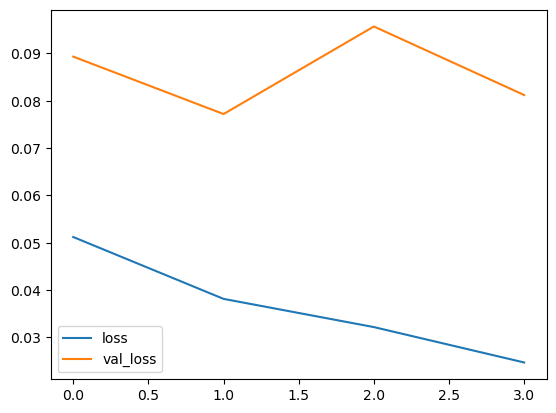

In [48]:
losses[['loss','val_loss']].plot()

<Axes: >

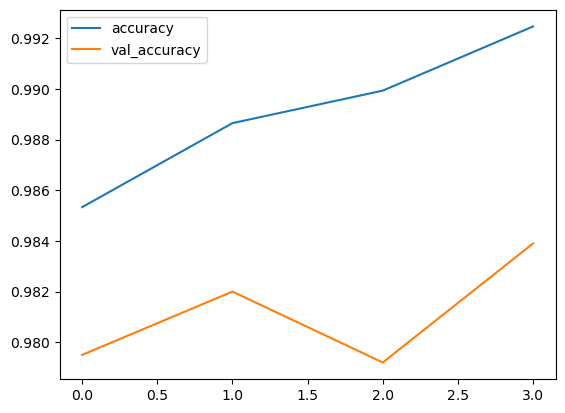

In [49]:
losses[['accuracy','val_accuracy']].plot()

In [50]:
model.evaluate(x_test,y_cat_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9839 - loss: 0.0812


[0.08119477331638336, 0.9839000105857849]

In [52]:
y_test_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [59]:
from sklearn.metrics import classification_report, confusion_matrix

In [53]:
y_test_pred.shape

(10000, 10)

In [54]:
y_test_pred[0]

array([7.7826585e-17, 1.2902177e-10, 4.3347026e-13, 5.9150693e-09,
       6.8063909e-11, 4.8263959e-16, 5.7941495e-20, 1.0000000e+00,
       2.0753598e-12, 2.9107829e-08], dtype=float32)

In [55]:
y_test_pred_classes = np.argmax(y_test_pred,axis = 1)

In [56]:
y_test_pred_classes.shape

(10000,)

In [62]:
y_test_pred_classes[0]

np.int64(7)

In [60]:
print(classification_report(y_test,y_test_pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.97      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [63]:
confusion_matrix(y_test, y_test_pred_classes)

array([[ 972,    0,    1,    0,    0,    0,    3,    1,    1,    2],
       [   0, 1131,    2,    1,    0,    0,    0,    0,    1,    0],
       [   1,    0, 1027,    1,    2,    0,    0,    1,    0,    0],
       [   0,    0,    3,  998,    0,    4,    0,    2,    0,    3],
       [   0,    5,    1,    0,  963,    2,    1,    0,    2,    8],
       [   2,    2,    0,    7,    0,  876,    3,    0,    2,    0],
       [   5,    4,    0,    1,    4,    3,  937,    1,    3,    0],
       [   0,    7,    8,    1,    3,    0,    0,  997,    1,   11],
       [   2,    0,    4,    5,    1,    3,    0,    2,  951,    6],
       [   0,    3,    2,    4,    4,    4,    0,    2,    3,  987]])

In [64]:
inference_image = x_test[225]

In [65]:
print(inference_image.max(),inference_image.min())

254 0


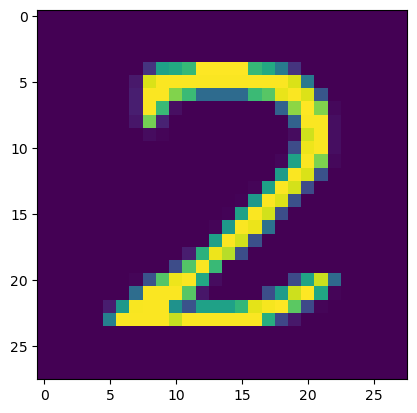

In [66]:
plt.imshow(inference_image)